# Main cross-validation and ablations

Source: archived main notebook, cells 25–41 and 73–77. Aligned rows and held-out reaction exclusion replace the error-prone indexing in the archived notebook. The first-stage feature for second-stage training rows remains in-sample as in the original protocol.


In [1]:
from pathlib import Path
import os
import sys

def repository_root(start):
    for path in (start, *start.parents):
        if (path / "Code" / "model_train.py").is_file():
            return path
    raise FileNotFoundError("Start Jupyter inside the CycloAddGenerator repository.")

REPO_ROOT = repository_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "notebooks" / "03_modeling"))
DATA_DIR = REPO_ROOT / "Data" / "DFT_Result"
DESCRIPTOR_MAP = REPO_ROOT / "Data" / "Descriptors" / "Descriptors_.pkl"

In [2]:
import numpy as np
import pandas as pd
from _modeling_common import (PHYSORG_FEATURE_COUNT, TARGET_COLUMNS,
    broad_training_ids, evaluate_targets, fit_delta_g_feature,
    load_modeling_data, metrics, new_catboost)

data_Ga, X_Ga, data_G, X_G = load_modeling_data(DATA_DIR, DESCRIPTOR_MAP)
Y_DD = data_Ga["Diene_Distort"].to_numpy()
Y_ED = data_Ga["Ene_Distort"].to_numpy()
Y_IN = data_Ga["Interaction"].to_numpy()
Y_Ga = data_Ga["deltaGa(Solvent)"].to_numpy()
Y_G = data_Ga["deltaG"].to_numpy()
Y_G_data_G = data_G["deltaG"].to_numpy()
print(f"Aligned active-energy rows: {len(data_Ga):,}; broad rows: {len(data_G):,}")

100%|██████████| 50161/50161 [00:06<00:00, 7393.07it/s]


Aligned active-energy rows: 8,273; broad rows: 50,161


In [3]:
from sklearn.model_selection import KFold

FOLDS = list(KFold(5, shuffle=True, random_state=0).split(X_Ga))
VARIANTS = ["PhysOrg", "PhysOrg + SVO",
            "PhysOrg + SVO + predicted reaction energy (active only)",
            "PhysOrg + SVO + predicted reaction energy (broad)"]

def features_for_split(variant, train_ids, test_ids):
    if variant == "PhysOrg":
        return X_Ga[:, :PHYSORG_FEATURE_COUNT]
    if variant == "PhysOrg + SVO":
        return X_Ga
    source = "active" if variant.endswith("(active only)") else "broad"
    pred_g = fit_delta_g_feature(data_G, X_G, data_Ga, X_Ga,
                                 train_ids, test_ids, source=source)
    return np.column_stack([X_Ga, pred_g])

cv_rows = []
oof = {variant: {label: np.full(len(data_Ga), np.nan)
                 for label in TARGET_COLUMNS} for variant in VARIANTS}
for variant in VARIANTS:
    for fold, (train_ids, test_ids) in enumerate(FOLDS):
        rows, predictions = evaluate_targets(
            data_Ga, features_for_split(variant, train_ids, test_ids),
            train_ids, test_ids)
        cv_rows.extend({"variant": variant, "fold": fold, **row} for row in rows)
        for label, (ids, values) in predictions.items():
            oof[variant][label][ids] = values
cv_results = pd.DataFrame(cv_rows)
display(cv_results.groupby(["variant", "target"])[["r2", "mae", "rmse"]].agg(["mean", "std"]))

r2  \
                                                                                       mean   
variant                                            target                                     
PhysOrg                                            Aqueous activation free energy  0.892250   
                                                   Diene distortion                0.927181   
                                                   Ene distortion                  0.743087   
                                                   Interaction                     0.731161   
PhysOrg + SVO                                      Aqueous activation free energy  0.913849   
                                                   Diene distortion                0.934075   
                                                   Ene distortion                  0.815824   
                                                   Interaction                     0.785182   
PhysOrg + SVO + predicted reaction energy (acti... Aqueous activation free energy  0.915906   
                                                   Diene distortion                0.934866   
                                                   Ene distortion                  0.818966   
                                                   Interaction                     0.786024   
PhysOrg + SVO + predicted reaction energy (broad)  Aqueous activation free energy  0.922491   
                                                   Diene distortion                0.937146   
                                                   Ene distortion                  0.824826   
                                                   Interaction                     0.786437   

                                                                                             \
                                                                                        std   
variant                                            target                                     
PhysOrg                                            Aqueous activation free energy  0.008336   
                                                   Diene distortion                0.003111   
                                                   Ene distortion                  0.009711   
                                                   Interaction                     0.011212   
PhysOrg + SVO                                      Aqueous activation free energy  0.006036   
                                                   Diene distortion                0.002007   
                                                   Ene distortion                  0.007855   
                                                   Interaction                     0.006116   
PhysOrg + SVO + predicted reaction energy (acti... Aqueous activation free energy  0.005194   
                                                   Diene distortion                0.002214   
                                                   Ene distortion                  0.007788   
                                                   Interaction                     0.007870   
PhysOrg + SVO + predicted reaction energy (broad)  Aqueous activation free energy  0.006205   
                                                   Diene distortion                0.001350   
                                                   Ene distortion                  0.005105   
                                                   Interaction                     0.009000   

                                                                                        mae  \
                                                                                       mean   
variant                                            target                                     
PhysOrg                                            Aqueous activation free energy  1.872894   
                                                   Diene distortion                1.180325   
  

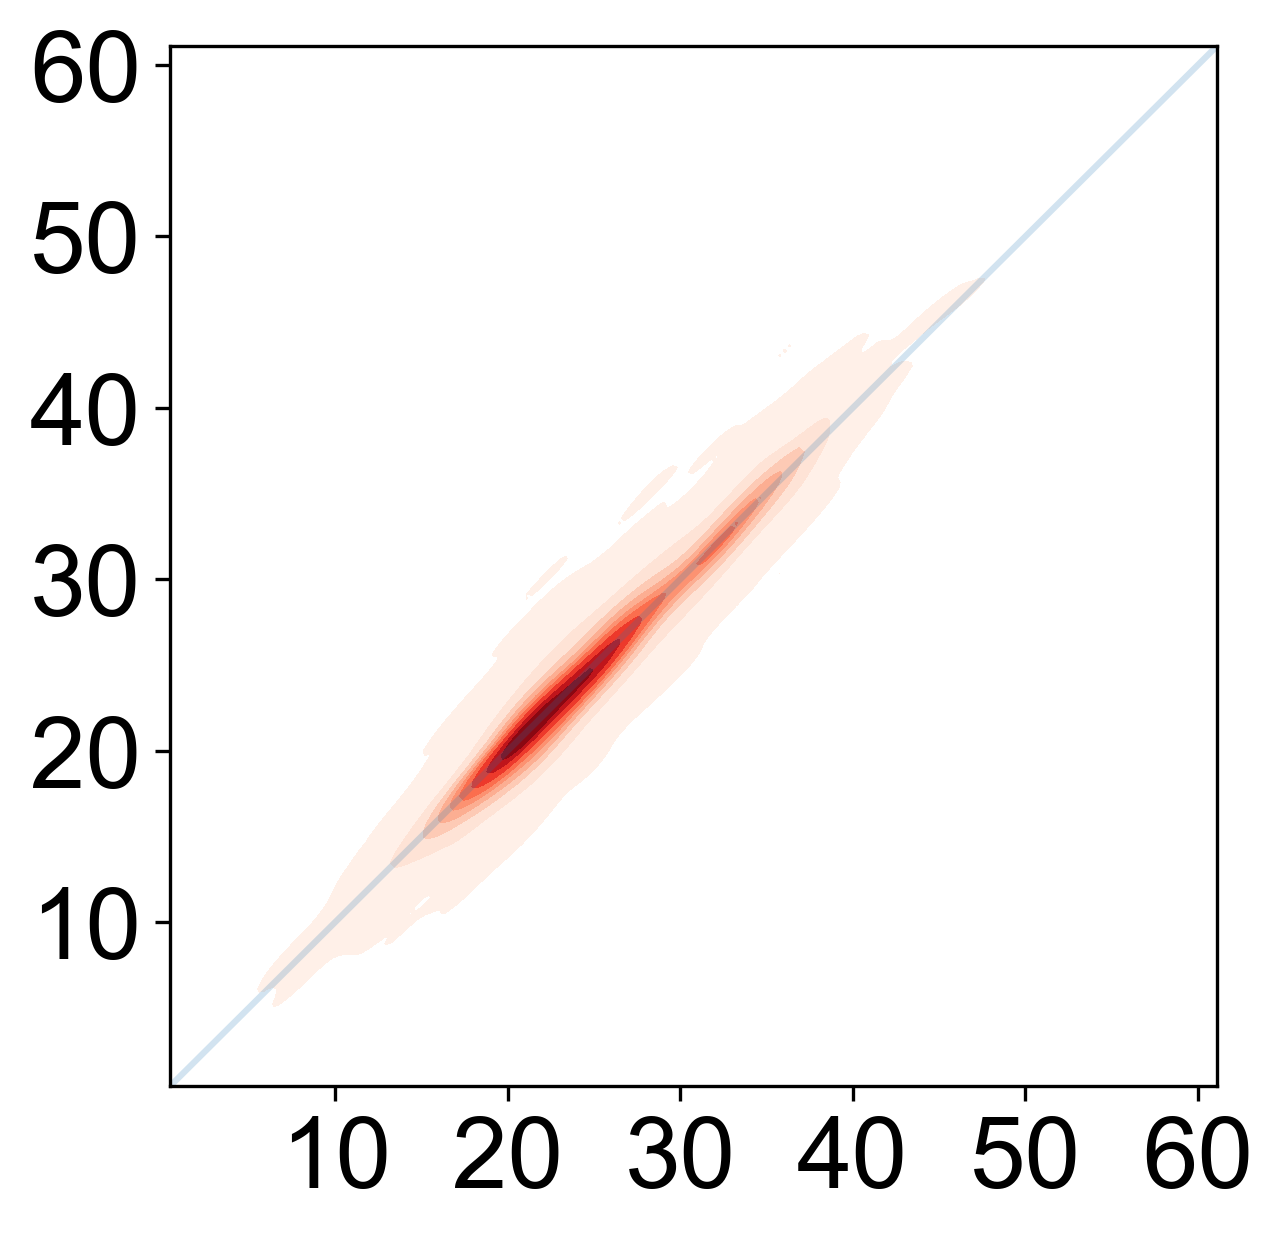

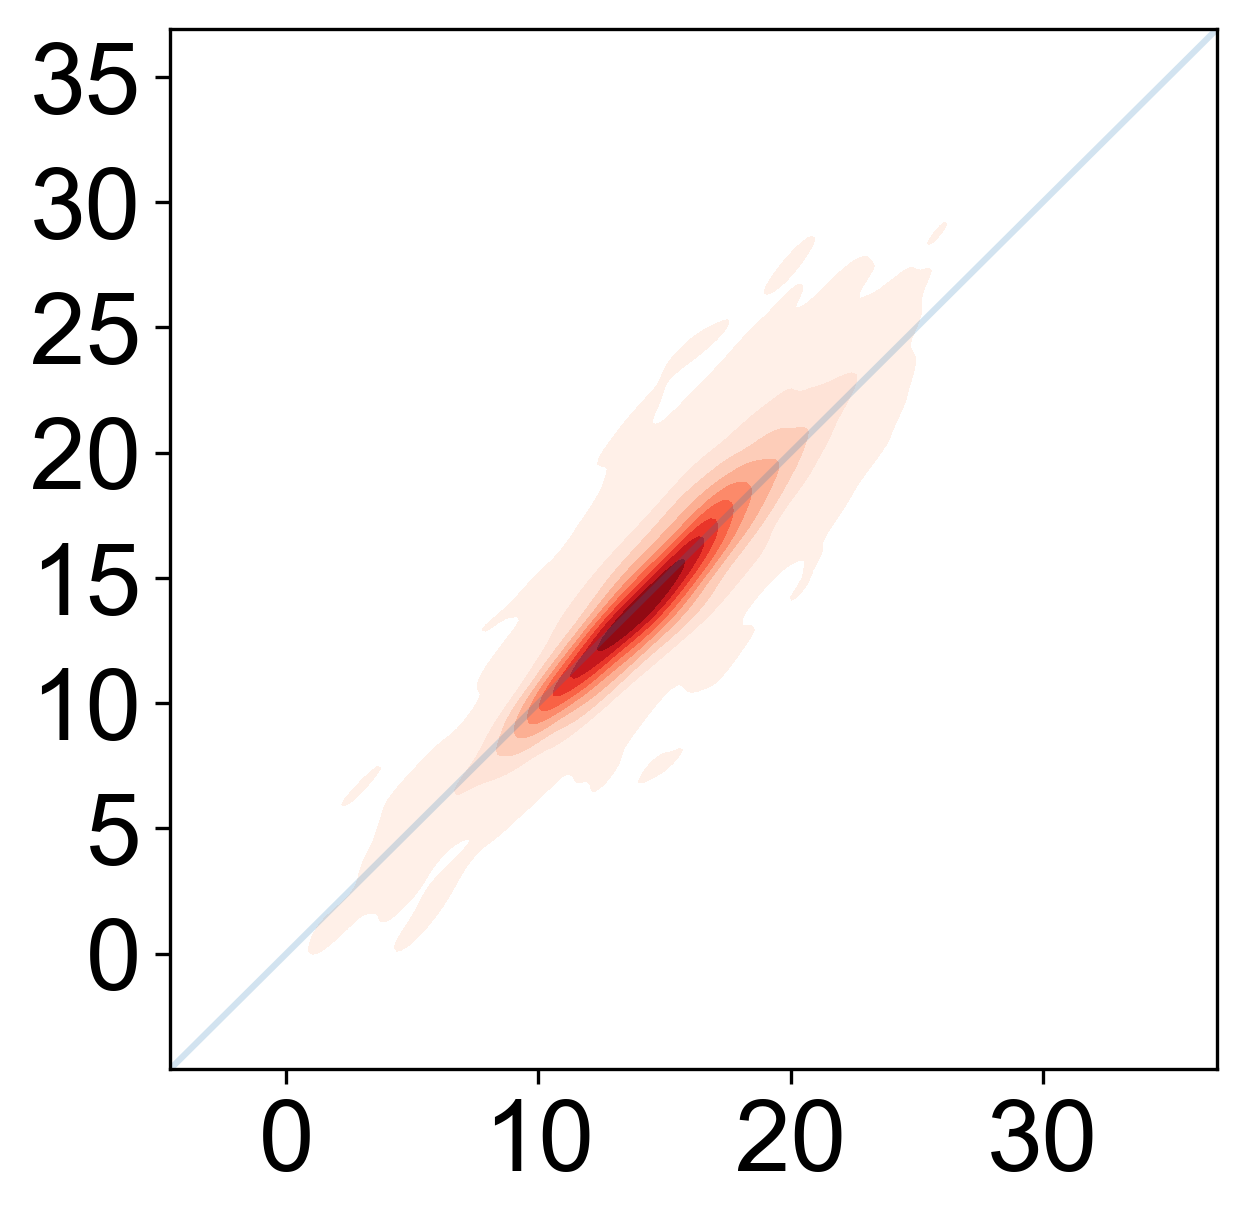

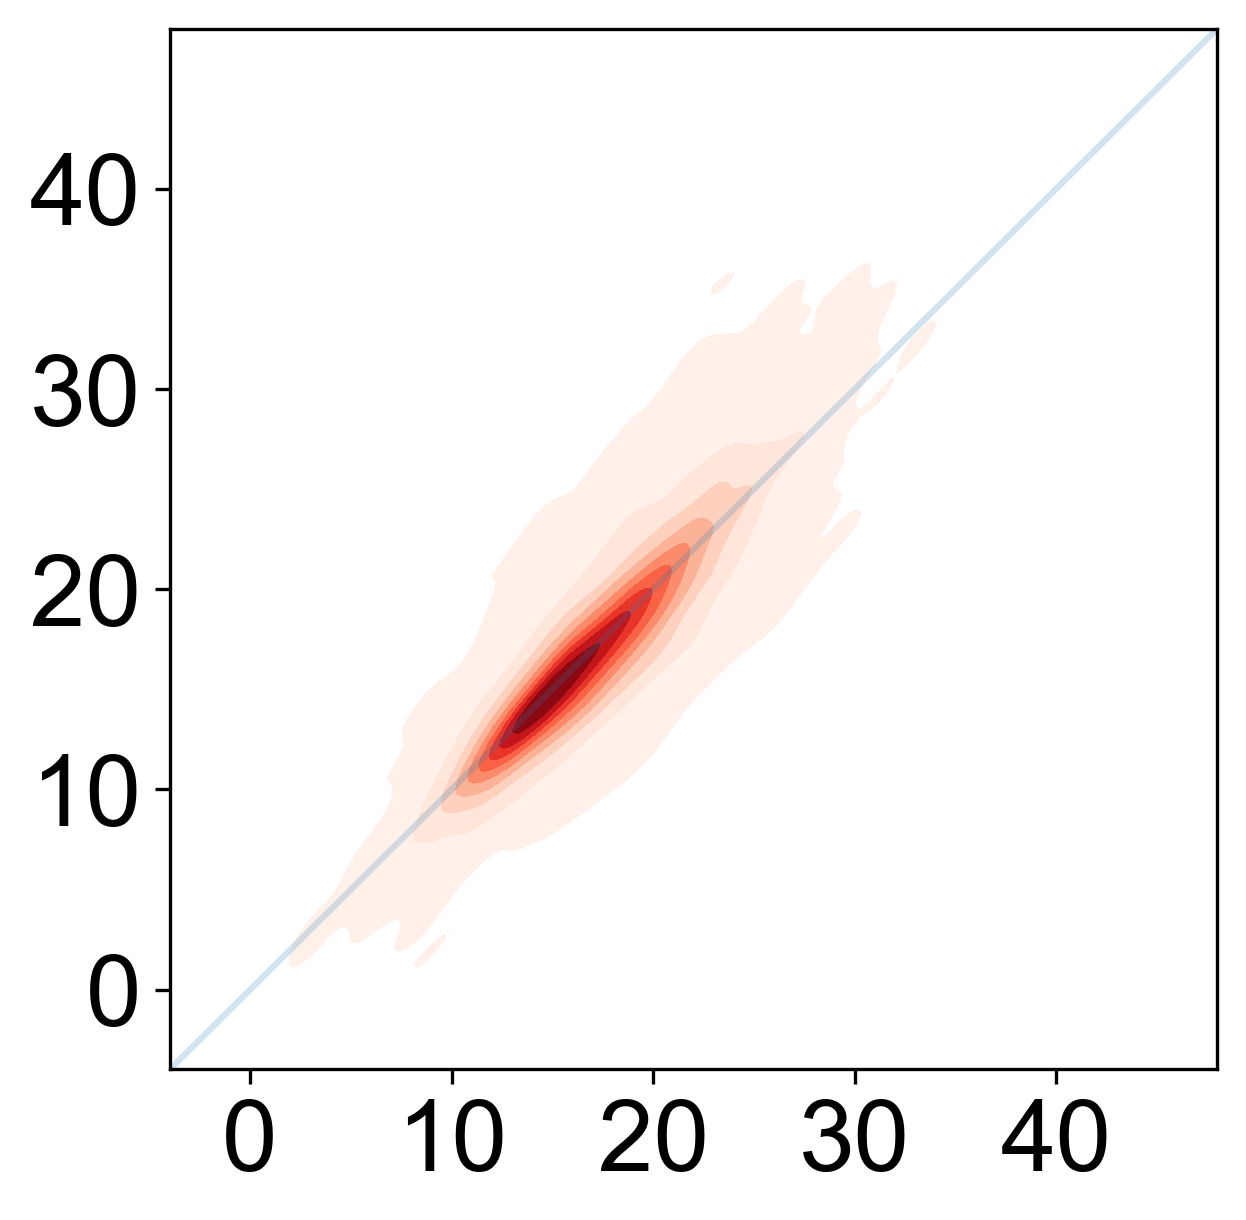

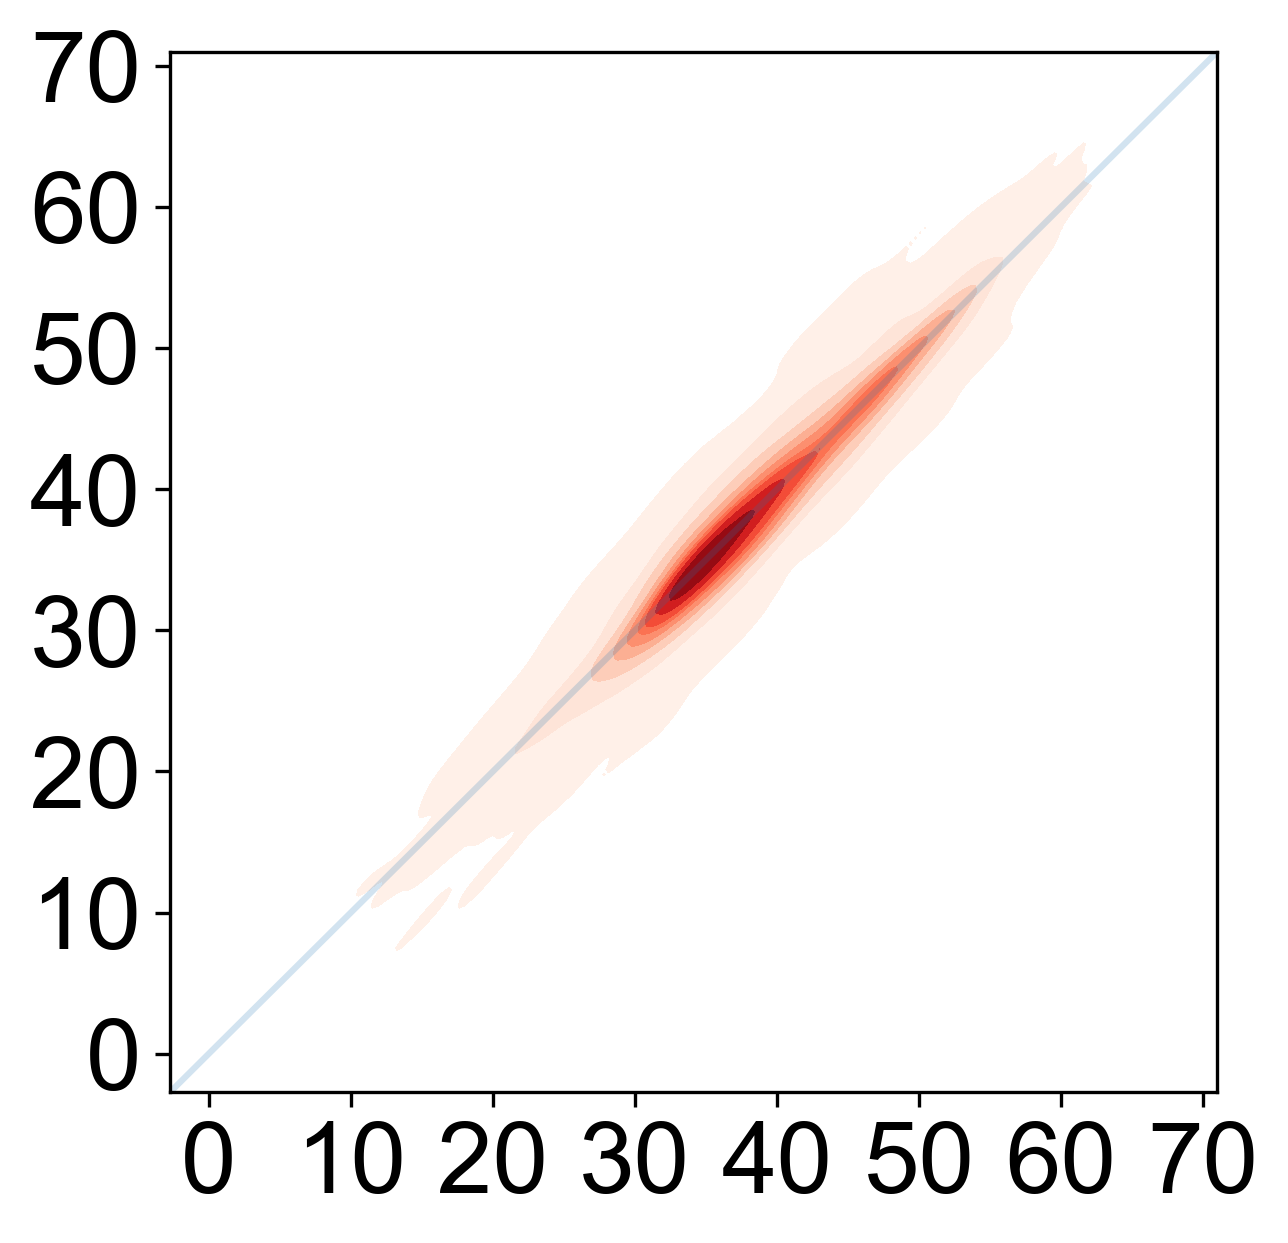

In [4]:
from Code import model_train

for label, column in TARGET_COLUMNS.items():
    model_train.plot_scatter_with_metrics(
        oof[VARIANTS[-1]][label], data_Ga[column].to_numpy(), alpha=0.1)

## Reaction free energy model


In [5]:
reaction_rows = []
for dataset, frame, features in [("Rxn: PhysOrg + SVO", data_G, X_G),
                                 ("Active: PhysOrg", data_Ga, X_Ga[:, :PHYSORG_FEATURE_COUNT]),
                                 ("Active: PhysOrg + SVO", data_Ga, X_Ga)]:
    y = frame["deltaG"].to_numpy()
    for fold, (train_ids, test_ids) in enumerate(
            KFold(5, shuffle=True, random_state=0).split(features)):
        model = new_catboost()
        model.fit(features[train_ids], y[train_ids])
        reaction_rows.append({"dataset": dataset, "fold": fold,
                              **metrics(y[test_ids], model.predict(features[test_ids]))})
for fold, (train_ids, test_ids) in enumerate(FOLDS):
    pred_g = fit_delta_g_feature(data_G, X_G, data_Ga, X_Ga,
                                 train_ids, test_ids, source="broad")
    reaction_rows.append({"dataset": "Active: broad-data transfer", "fold": fold,
                          **metrics(Y_G[test_ids], pred_g[test_ids])})
reaction_energy_cv = pd.DataFrame(reaction_rows)
display(reaction_energy_cv.groupby("dataset")[["r2", "mae", "rmse"]].agg(["mean", "std"]))

r2                 mae                rmse  \
                                 mean       std      mean       std      mean   
dataset                                                                         
Active: PhysOrg              0.956326  0.002961  1.705723  0.035979  2.460476   
Active: PhysOrg + SVO        0.957920  0.002661  1.680060  0.031079  2.415400   
Active: broad-data transfer  0.941358  0.005955  2.113720  0.081709  2.851321   
Rxn: PhysOrg + SVO           0.982725  0.000929  2.436178  0.016822  3.640285   

                                       
                                  std  
dataset                                
Active: PhysOrg              0.052483  
Active: PhysOrg + SVO        0.048510  
Active: broad-data transfer  0.167089  
Rxn: PhysOrg + SVO           0.091451

## Feature importance


In [6]:
all_ids = np.arange(len(data_Ga))
pred_g = fit_delta_g_feature(data_G, X_G, data_Ga, X_Ga,
                             all_ids, all_ids, source="broad")
features = np.column_stack([X_Ga, pred_g])
feature_names = (model_train.ALL_PROPERTIES_diene + model_train.ALL_PROPERTIES_ene
                 + model_train.New_des + ["predicted reaction energy"])
if len(feature_names) != features.shape[1]:
    raise ValueError("Feature names and descriptor columns differ.")
importance_rows = []
for label, column in TARGET_COLUMNS.items():
    model = new_catboost()
    model.fit(features, data_Ga[column].to_numpy())
    importance_rows.extend({"target": label, "feature": name, "importance": value}
                           for name, value in zip(feature_names, model.feature_importances_))
importance = pd.DataFrame(importance_rows)
display(importance.sort_values("importance", ascending=False).groupby("target").head(10))

,target,feature,importance
259,Aqueous activation free energy,predicted reaction energy,14.575796
129,Ene distortion,predicted reaction energy,14.197998
64,Diene distortion,predicted reaction energy,14.046346
13,Diene distortion,angle_b_cos,11.765687
208,Aqueous activation free energy,angle_b_cos,9.878788
11,Diene distortion,distance_ad,9.828030
49,Diene distortion,diene_area_1,9.252803
206,Aqueous activation free energy,distance_ad,7.322401
214,Aqueous activation free energy,diene_lumo,6.805033
94,Ene distortion,ene_charge_f,6.090811
